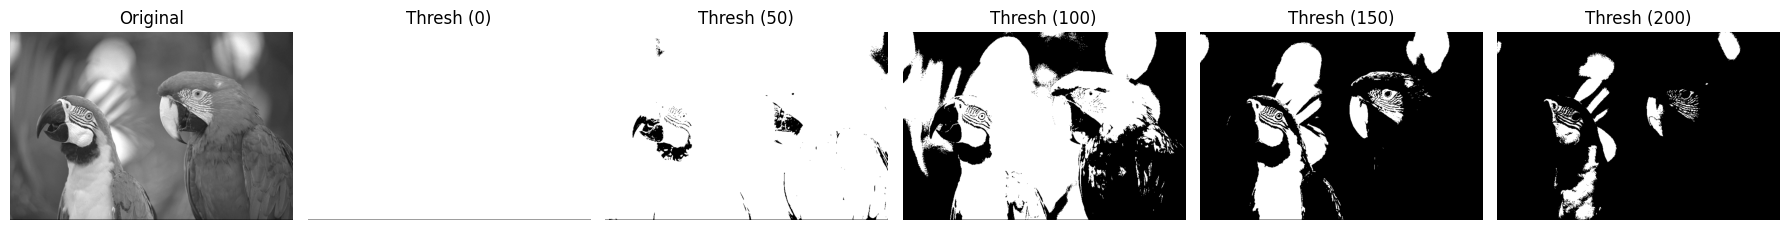

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('Parrot.png', cv2.IMREAD_GRAYSCALE)
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(18, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    axes[i + 1].imshow(thresh, cmap='gray')
    axes[i + 1].set_title(f'Thresh ({threshold_value})')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

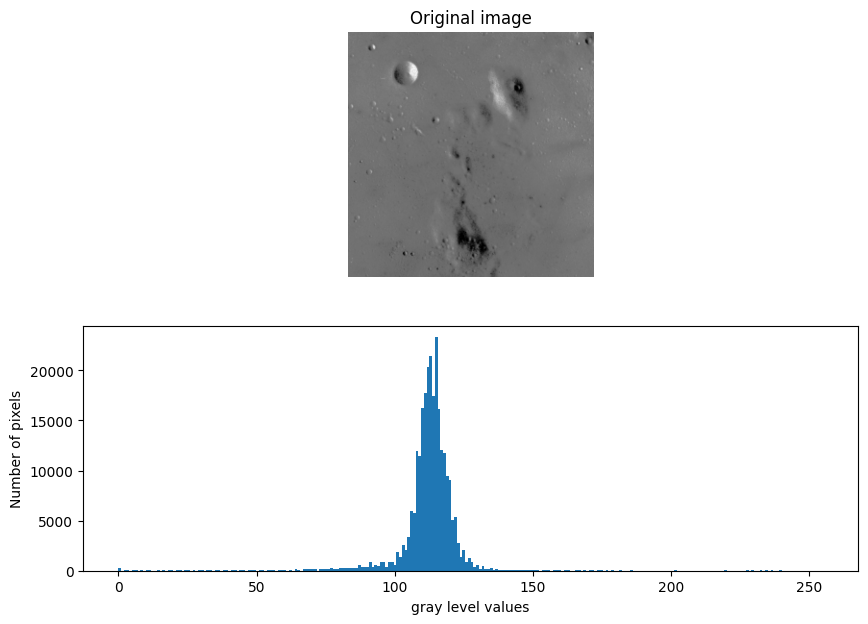

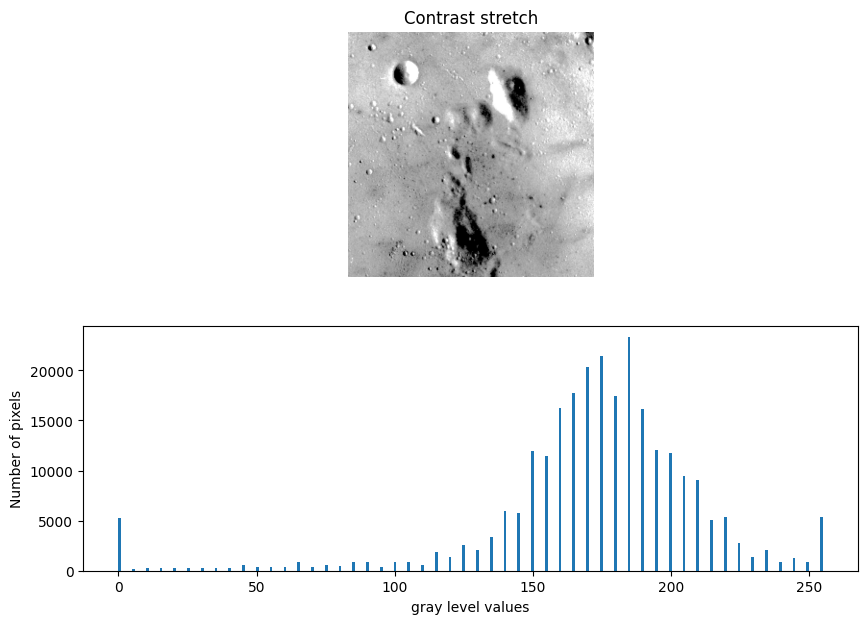

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage import exposure

img = data.moon()

p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

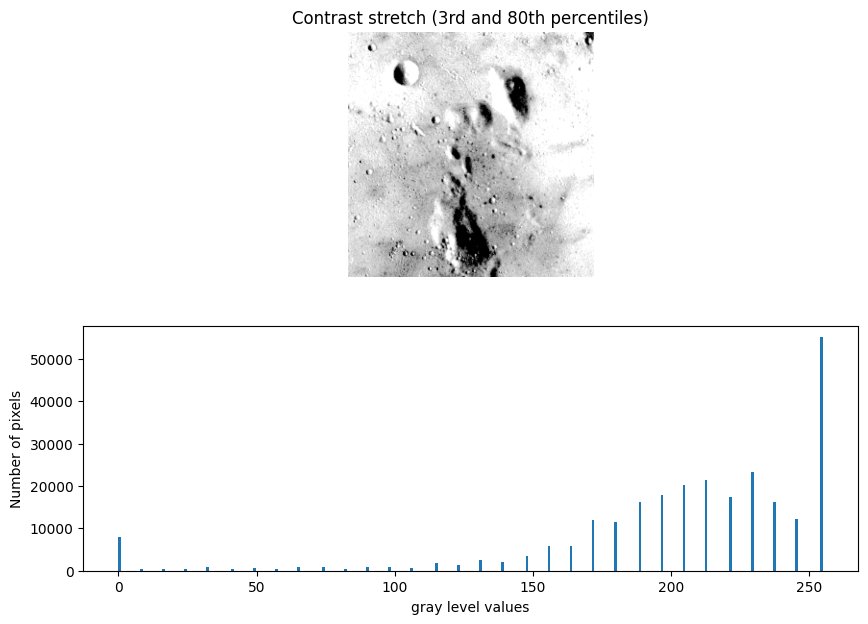

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage import exposure

img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd and 80th percentiles)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

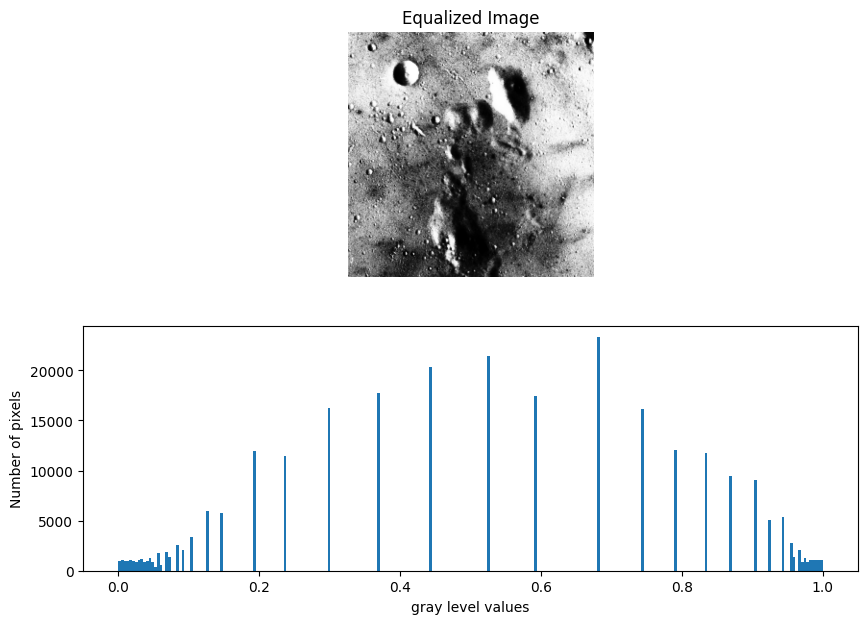

In [6]:
import matplotlib.pyplot as plt
from skimage import data
from skimage import exposure

img = data.moon()

img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Equalized Image')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

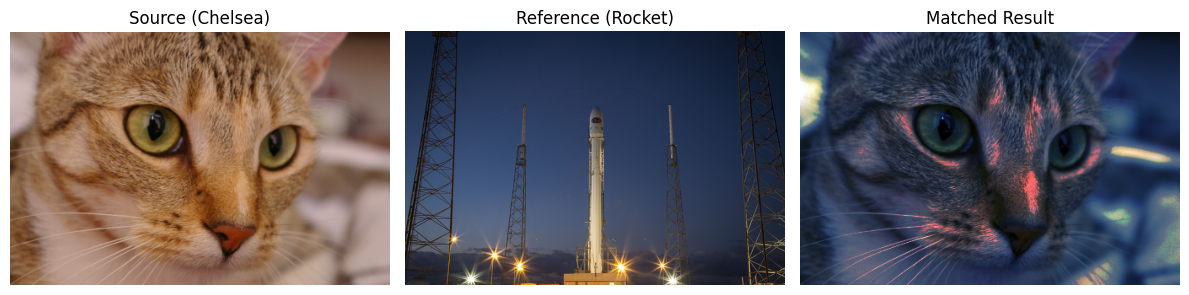

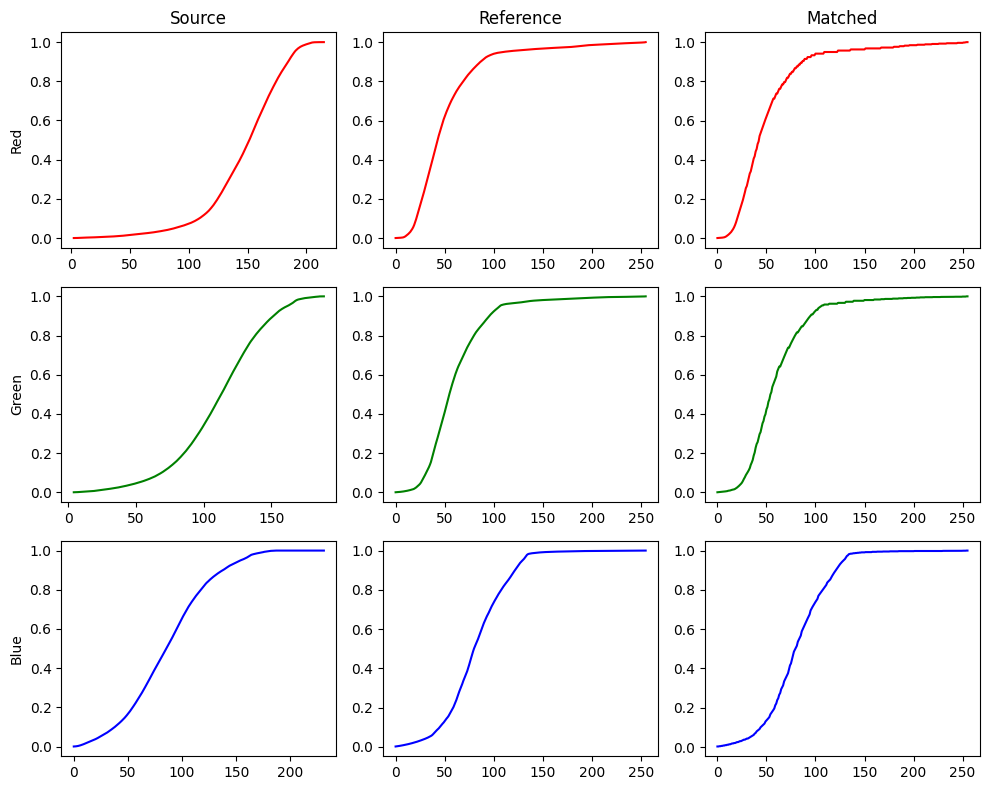

In [7]:
import matplotlib.pyplot as plt
from skimage import data
from skimage import exposure
from skimage.exposure import match_histograms

reference = data.rocket()
image = data.chelsea()

matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title('Source (Chelsea)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference (Rocket)')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Matched Result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 8))

for i, current_img in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.cumulative_distribution(current_img[..., c])
        axes[c, i].plot(bins, img_hist, color=c_color)

axes[0, 0].set_title('Source')
axes[0, 1].set_title('Reference')
axes[0, 2].set_title('Matched')

axes[0, 0].set_ylabel('Red')
axes[1, 0].set_ylabel('Green')
axes[2, 0].set_ylabel('Blue')

plt.tight_layout()
plt.show()